In [17]:
# Preliminaries -----------------------------------------------------------
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, haven)

In [18]:
final.hcris <- read_tsv("../data/output/HCRIS_Data.txt")

Rows: 161060 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [19]:
# price variables
new.final.hcris <- final.hcris %>% 
  mutate(
    discount_factor = 1-tot_discounts/tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges)*discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    est_price = price_num/price_denom
  ) %>% 
  mutate(est_price = ifelse(est_price < 0, NA, est_price)) %>% # set negative prices to NA
  mutate(
    p99 = quantile(est_price, 0.99, na.rm = TRUE), # drop outlier prices
    p01 = quantile(est_price, 0.01, na.rm = TRUE),
    est_price = ifelse(est_price < p01 | est_price > p99, NA, est_price)) %>% 
  drop_na(est_price) %>%
  select(-p99, -p01) %>%
  mutate(
    hvbp_payment = ifelse(is.na(hvbp_payment), 0, hvbp_payment),
    hrrp_payment = ifelse(is.na(hrrp_payment), 0, abs(hrrp_payment))
  )

# penalty calculations
net_penalty <- new.final.hcris %>% 
  filter(year == 2012) %>% 
  mutate(net_penalty = hvbp_payment - hrrp_payment) %>% 
  select(provider_number, net_penalty)

# price change
price_change <- new.final.hcris %>% 
  filter(year %in% c(2011, 2014)) %>% 
  select(provider_number, year, est_price) %>% 
  pivot_wider(names_from = year, values_from = est_price, names_prefix = "price_") %>% 
  mutate(price_change = price_2014 - price_2011) %>% 
  select(provider_number, price_change)

# pre-2012 variables
pre_2012 <- new.final.hcris %>%
  filter(year %in% c(2009:2011)) %>%
  group_by(provider_number) %>%
  summarize(
    mean_mcare = mean(mcare_discharges, na.rm = TRUE),
    mean_beds = mean(beds, na.rm = TRUE),
    mean_mcaid = mean(mcaid_discharges, na.rm = TRUE)
  ) %>% ungroup()

# merge data for price change
merged_data <- price_change %>% 
  inner_join(net_penalty, by = "provider_number") %>% 
  inner_join(pre_2012, by = "provider_number") %>% 
  filter (!is.na(price_change), !is.na(net_penalty), 
     !is.na(mean_mcare),!is.na(mean_mcaid))  

new.final.hcris %>% 
  filter(source =="weighted_average")

provider_number,fy_start,fy_end,date_processed,date_created,data_source,beds,tot_charges,net_pat_rev,tot_discounts,⋯,tot_uncomp_care_charges,tot_uncomp_care_partial_pmts,bad_debt,accum_dep,year,source,discount_factor,price_num,price_denom,est_price
<chr>,<date>,<date>,<date>,<date>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
010012,2023-04-01,2024-12-31,2025-06-06,2025-06-03,NA,97,446571221,44472717,402098504,⋯,NA,NA,NA,1806603.35,2024,weighted_average,0.09958706,8570723.8,1929.5399,4441.848
010016,2009-10-01,2010-12-31,2011-06-28,2011-02-25,NA,192,657038543,113702136,543336407,⋯,NA,NA,NA,93907434.60,2010,weighted_average,0.17305246,41382867.9,5900.2000,7013.808
010024,2009-07-01,2010-12-31,2014-10-22,2011-01-25,NA,255,500669906,130967576,369702330,⋯,NA,NA,NA,129361378.51,2010,weighted_average,0.26158468,42407697.9,6660.7660,6366.790
010034,2002-07-01,2003-09-30,2005-03-15,2004-10-13,NA,69,25572712,15486963,10085749,⋯,NA,NA,NA,2408632.60,2003,weighted_average,0.60560502,2042364.1,799.2000,2555.511
010038,2016-07-01,2017-09-30,2018-11-14,2018-03-20,NA,125,344555341,28487742,316067599,⋯,1885443.76,13.36264,16439362,2153016.98,2017,weighted_average,0.08267973,2778963.8,1024.9011,2711.446
010046,2014-07-01,2015-12-31,2016-07-25,2015-10-23,NA,256,760393609,76556213,683837396,⋯,33211.07,1198.93967,33613448,24754006.34,2015,weighted_average,0.10067972,19684065.0,2897.1920,6794.187
010054,2010-07-01,2011-12-31,2014-07-23,2013-11-12,NA,109,240108319,36395607,203712711,⋯,3359662.40,NA,5295437,4231281.40,2011,weighted_average,0.15157995,8975795.3,1949.8208,4603.395
010055,2013-07-01,2014-09-30,2015-03-20,2014-12-17,NA,235,993595674,164610765,828984910,⋯,8527145.40,4886.80000,19245854,106152995.40,2014,weighted_average,0.16567178,42002987.9,5123.8000,8197.624
010059,2008-03-01,2009-09-30,2013-06-07,2010-04-07,NA,37,39132994,13855009,25277986,⋯,NA,NA,NA,1625843.65,2009,weighted_average,0.35404928,1181498.1,702.4419,1681.987


After creating the datasets, I calculated the estimated price using hospital cost report variables, and removed negative prices and observations in the bottom and top 1% to address outliers. I then constructed the data for questions 6-10. Price changes from 2011 to 2014 were calculated with simply subtracting the price from each year. Net penalty was a difference between hvbp and hrrp payment, and pre-period averages of Medicare discharges, bed size, and Medicaid discharges from 2009 to 2011 were also calculated.

## Problem 1

The number of hospitals filing more than one report does not decline over time, suggesting that there is not a significant improvement 

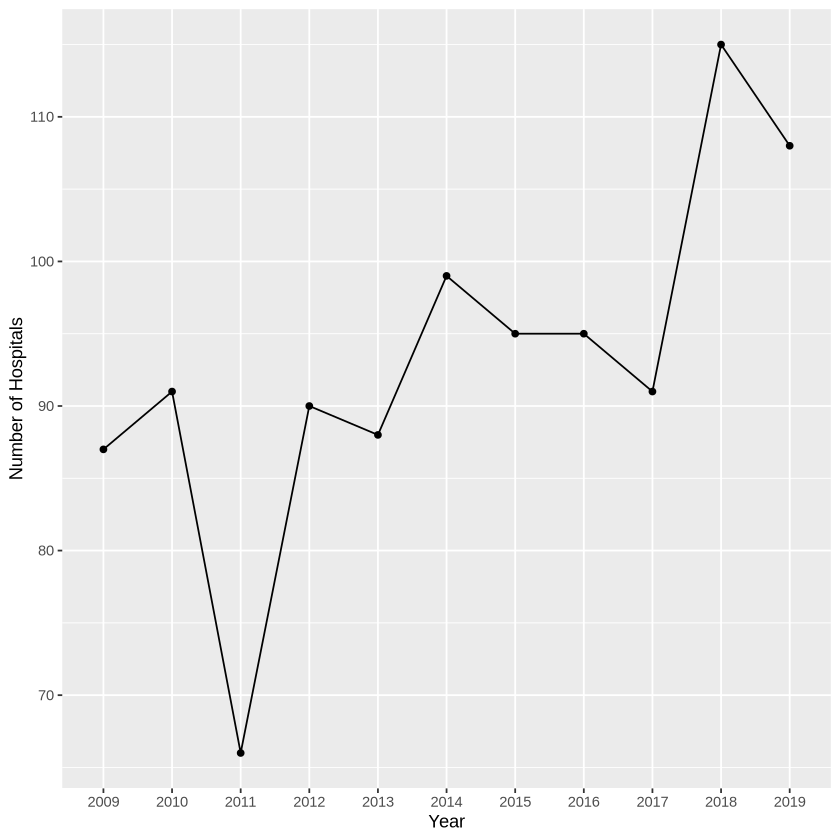

In [20]:
final.hcris %>% 
  group_by(source, year) %>% 
  filter((source == "total for year")|(source == "weighted_average"))%>%
  group_by(year) %>% 
  summarize("counts" = n()) %>% 
  filter(year >= 2009, year <= 2019) %>%
  ggplot(aes(x = as.factor(year), y = counts)) +
  geom_line(group=1) +
  geom_point() + 
  labs(
       x = "Year",
       y = "Number of Hospitals")

## Problem 2

There are consistently around 7,000 unique hospital IDs per year. 

In [21]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

final.hcris %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  group_by(year) %>%
  summarise(unique_hospitals = n_distinct(provider_number)) %>%
  kable(
    col.names = c("Year", "Unique Hospitals"),
    booktabs  = TRUE,
    caption   = "Unique Hospital IDs by Year"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Unique Hospital IDs by Year</caption>
 <thead>
  <tr>
   <th style="text-align:right;font-weight: bold;"> Year </th>
   <th style="text-align:right;font-weight: bold;"> Unique Hospitals </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2009 </td>
   <td style="text-align:right;"> 6100 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2010 </td>
   <td style="text-align:right;"> 6103 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2011 </td>
   <td style="text-align:right;"> 6097 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2012 </td>
   <td style="text-align:right;"> 6140 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2013 </td>
   <td style="text-align:right;"> 6066 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2014 </td>
   <td style="text-

## Problem 3

Total charges increased steadily from 2009-2019, which reflects growth in hospital billing across all hospital sizes.

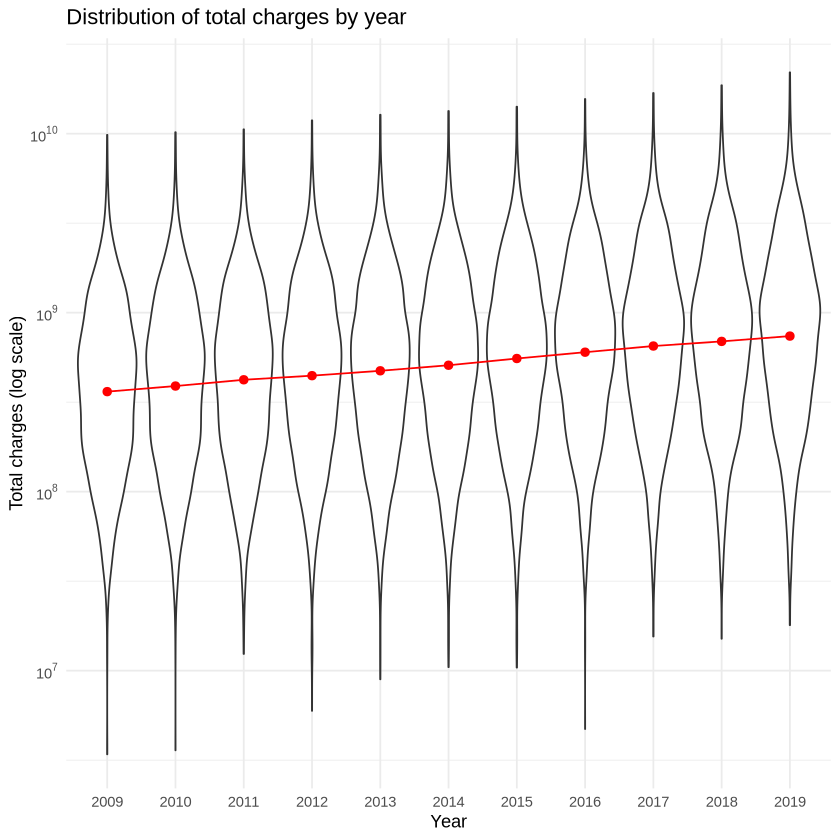

In [22]:
new.final.hcris %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  filter(tot_charges > 0) %>%
  ggplot(aes(x = factor(year), y = tot_charges)) +
  geom_violin() +
  stat_summary(fun = "mean", geom = "point", color = "red", size = 2) +
  stat_summary(fun = "mean", geom = "line", aes(group = 1), color = "red") +
  scale_y_log10(labels = scales::label_log(digits = 2)) +
  labs(
    title = "Distribution of total charges by year",
    x = "Year",
    y = "Total charges (log scale)"
  ) +
  theme_minimal()

## Problem 4

Estimated prices show an upward trend from 2009-2019, with a large variation across hospitals each year. The distribution centers around $10,000 per discharge.

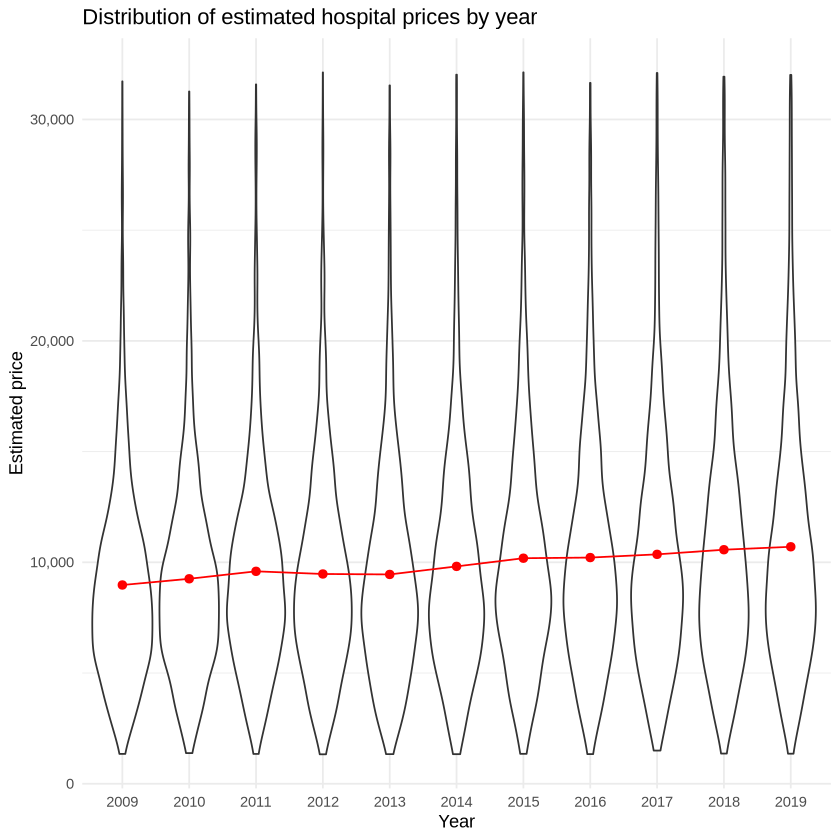

In [23]:
new.final.hcris %>%
  mutate(
    year = year(fy_end),
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(year >= 2009, year <= 2019) %>%
  ggplot(aes(x = factor(year), y = est_price)) +
  geom_violin() +
  stat_summary(fun = "mean", geom = "point", color = "red", size = 2) +
  stat_summary(fun = "mean", geom = "line", aes(group = 1), color = "red") +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Distribution of estimated hospital prices by year",
    x = "Year",
    y = "Estimated price"
  ) +
  theme_minimal()

## Problem 5

The share of hospitals penalized under HRRP/VBP rose sharply from 2012 to 2013 and remained relatively stable around 70% through 2019. The sharp increase can be attributed to the HRRP/VBP being instilled from 2010 with the Affordable Care Act. 

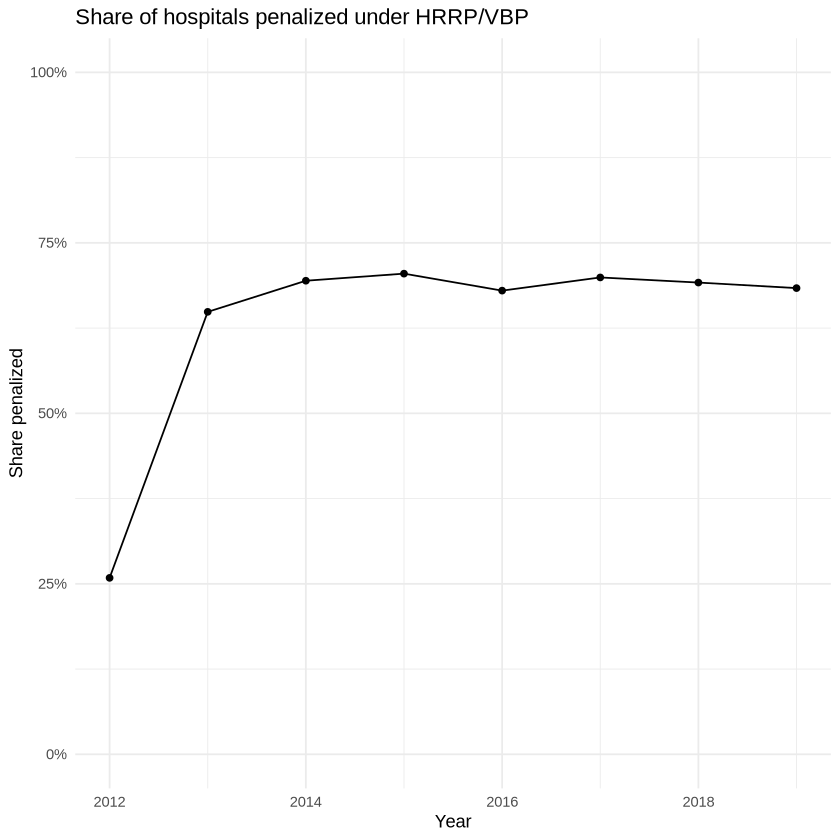

In [24]:
new.final.hcris %>%
  mutate(
    year = year(fy_end),
    penalty = as.numeric((hvbp_payment - hrrp_payment) < 0)
  ) %>%
  filter(year >= 2012, year <= 2019) %>%
  group_by(year) %>%
  summarise(share_penalized = mean(penalty, na.rm = TRUE)) %>%
  
ggplot(aes(x = year, y = share_penalized)) +
  geom_line() +
  geom_point() +
  scale_y_continuous(labels = scales::percent, limits = c(0, 1)) +
  labs(
    title = "Share of hospitals penalized under HRRP/VBP",
    x = "Year",
    y = "Share penalized"
  ) +
  theme_minimal()

## Problem 6
This table presents OLS estimates of the effect of net penalties on price changes across three different specifications. The coefficient on net penalty is small and negative across all specifications, which suggests slightly lower price growth in penalized hospitals, but this could be due to the endogeneity issue of penalty status. 

In [25]:
ols1 <- lm(price_change ~ net_penalty, data = merged_data)
ols2 <- lm(price_change ~ net_penalty + mean_beds, data = merged_data)
ols3 <- lm(price_change ~ net_penalty + mean_beds + mean_mcaid, data = merged_data)

summary(ols1)
summary(ols2)
summary(ols3)


Call:
lm(formula = price_change ~ net_penalty, data = merged_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-21473.9  -1237.7    -70.7   1200.7  21762.6 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 218.034431  55.164241   3.952 7.96e-05 ***
net_penalty  -0.003641   0.001357  -2.684  0.00733 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2625 on 2393 degrees of freedom
Multiple R-squared:  0.003001,	Adjusted R-squared:  0.002585 
F-statistic: 7.203 on 1 and 2393 DF,  p-value: 0.007327



Call:
lm(formula = price_change ~ net_penalty + mean_beds, data = merged_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-21462.6  -1229.8    -65.4   1197.3  21755.1 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 200.004335  55.741717   3.588  0.00034 ***
net_penalty  -0.003542   0.001356  -2.611  0.00907 ** 
mean_beds     0.074318   0.034183   2.174  0.02980 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2623 on 2392 degrees of freedom
Multiple R-squared:  0.004967,	Adjusted R-squared:  0.004135 
F-statistic: 5.971 on 2 and 2392 DF,  p-value: 0.002591



Call:
lm(formula = price_change ~ net_penalty + mean_beds + mean_mcaid, 
    data = merged_data)

Residuals:
   Min     1Q Median     3Q    Max 
-21420  -1240    -47   1204  21679 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 39.258417  68.247916   0.575   0.5652    
net_penalty -0.002931   0.001360  -2.154   0.0313 *  
mean_beds    0.064588   0.034158   1.891   0.0588 .  
mean_mcaid   0.102904   0.025370   4.056 5.15e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2614 on 2391 degrees of freedom
Multiple R-squared:  0.01177,	Adjusted R-squared:  0.01053 
F-statistic:  9.49 on 3 and 2391 DF,  p-value: 3.129e-06


In [26]:
fmt_p <- function(p) ifelse(is.na(p), NA, sprintf("%.3f", p))

data.frame(
  Statistic = c(
    "Intercept", "p-value",
    "Net Penalty", "p-value",
    "Mean Beds (Pre-2012)", "p-value",
    "Mean Medicaid Discharges (Pre-2012)", "p-value",
    "# Obs", "R2"
  ),
  `OLS 1` = c(
    round(coef(ols1)["(Intercept)"], 3),
    fmt_p(coef(summary(ols1))["(Intercept)", "Pr(>|t|)"]),
    round(coef(ols1)["net_penalty"], 3),
    fmt_p(coef(summary(ols1))["net_penalty", "Pr(>|t|)"]),
    NA, NA, NA, NA,
    nobs(ols1), round(summary(ols1)$r.squared, 3)
  ),
  `OLS 2` = c(
    round(coef(ols2)["(Intercept)"], 3),
    fmt_p(coef(summary(ols2))["(Intercept)", "Pr(>|t|)"]),
    round(coef(ols2)["net_penalty"], 3),
    fmt_p(coef(summary(ols2))["net_penalty", "Pr(>|t|)"]),
    round(coef(ols2)["mean_beds"], 3),
    fmt_p(coef(summary(ols2))["mean_beds", "Pr(>|t|)"]),
    NA, NA,
    nobs(ols2), round(summary(ols2)$r.squared, 3)
  ),
  `OLS 3` = c(
    round(coef(ols3)["(Intercept)"], 3),
    fmt_p(coef(summary(ols3))["(Intercept)", "Pr(>|t|)"]),
    round(coef(ols3)["net_penalty"], 3),
    fmt_p(coef(summary(ols3))["net_penalty", "Pr(>|t|)"]),
    round(coef(ols3)["mean_beds"], 3),
    fmt_p(coef(summary(ols3))["mean_beds", "Pr(>|t|)"]),
    round(coef(ols3)["mean_mcaid"], 3),
    fmt_p(coef(summary(ols3))["mean_mcaid", "Pr(>|t|)"]),
    nobs(ols3), round(summary(ols3)$r.squared, 3)
  ),
  check.names = FALSE
) %>%
  kable(
    col.names = c("Statistic", "OLS 1", "OLS 2", "OLS 3"),
    digits = 3, booktabs = TRUE,
    caption = "OLS Estimates of Net Penalty on Price Changes"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(c(2, 4, 6, 8), italic = TRUE, color = "gray") %>%
  pack_rows("Coefficients", 1, 8) %>%
  pack_rows("Model Fit", 9, 10)


<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>OLS Estimates of Net Penalty on Price Changes</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Statistic </th>
   <th style="text-align:left;font-weight: bold;"> OLS 1 </th>
   <th style="text-align:left;font-weight: bold;"> OLS 2 </th>
   <th style="text-align:left;font-weight: bold;"> OLS 3 </th>
  </tr>
 </thead>
<tbody>
  <tr grouplength="8"><td colspan="4" style="border-bottom: 1px solid;"><strong>Coefficients</strong></td></tr>
<tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Intercept </td>
   <td style="text-align:left;"> 218.034 </td>
   <td style="text-align:left;"> 200.004 </td>
   <td style="text-align:left;"> 39.258 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;font-style: italic;color: gray !important;padding-left: 2em;" indentlevel="1"> p-value </td>
   <td style="text-align:left;font-style: italic;color

## Problem 7
The scatterplot shows a negative relationship between net penalty and pre-2012 Medicare discharges. This suggests that hospitals with a larger proportion of Medicare patient tended to receive larger net penalties. 

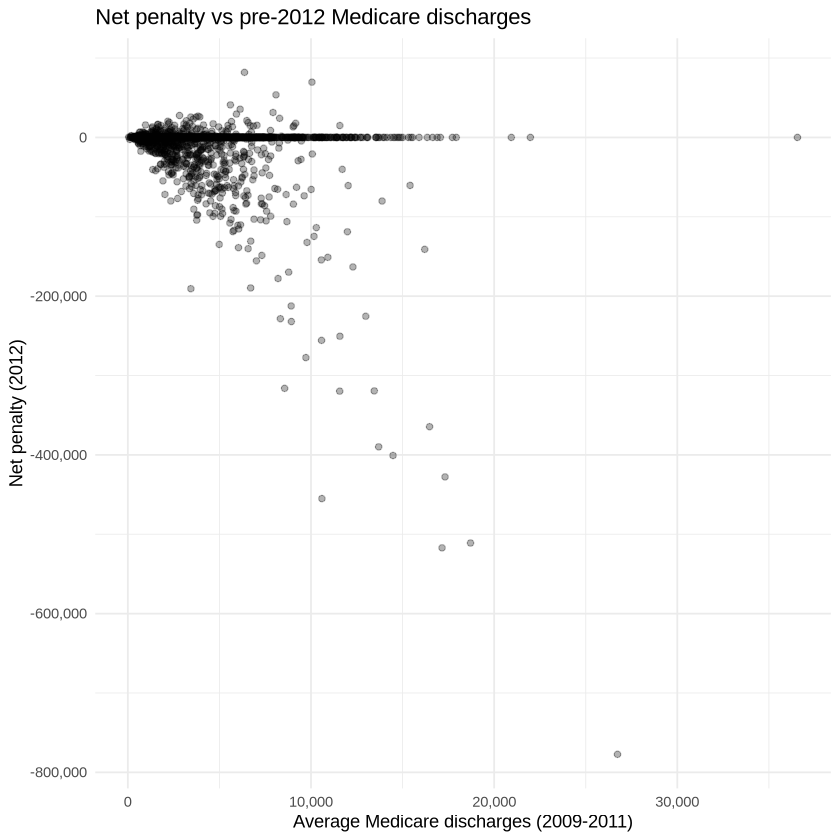

In [27]:
ggplot(merged_data, aes(x = mean_mcare, y = net_penalty)) +
  geom_point(alpha = 0.3) +
  scale_x_continuous(labels = scales::comma) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Net penalty vs pre-2012 Medicare discharges",
    x = "Average Medicare discharges (2009-2011)",
    y = "Net penalty (2012)"
  ) +
  theme_minimal()

## Problem 8
The first stage shows a strong negative relationship between pre-2012 Medicare discharges and net penalty. This confirms that Medicare discharge share is a good instrument. The reduced form shows a weaker but direct relationship between Medicare discharges and price changes.

In [28]:
library(fixest)

# First stage: net_penalty with mean_mcare as instrument
fs1 <- feols(net_penalty ~ mean_mcare, data = merged_data)
fs2 <- feols(net_penalty ~ mean_mcare + mean_beds, data = merged_data)
fs3 <- feols(net_penalty ~ mean_mcare + mean_beds + mean_mcaid, data = merged_data)

# Reduced form: price_change with mean_mcare as instrument
rf1 <- feols(price_change ~ mean_mcare, data = merged_data)
rf2 <- feols(price_change ~ mean_mcare + mean_beds, data = merged_data)
rf3 <- feols(price_change ~ mean_mcare + mean_beds + mean_mcaid, data = merged_data)

cat("=== First Stage ===\n")
summary(fs1)
summary(fs2)
summary(fs3)

cat("=== Reduced Form ===\n")
summary(rf1)
summary(rf2)
summary(rf3)


=== First Stage ===


OLS estimation, Dep. Var.: net_penalty
Observations: 2,395 
Standard-errors: IID 
              Estimate  Std. Error   t value   Pr(>|t|)    
(Intercept) 6128.38525 1167.581876   5.24878 1.6658e-07 ***
mean_mcare    -4.27618    0.242429 -17.63891  < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 37,195.4   Adj. R2: 0.114688

OLS estimation, Dep. Var.: net_penalty
Observations: 2,395 
Standard-errors: IID 
               Estimate  Std. Error    t value   Pr(>|t|)    
(Intercept) 6126.161155 1168.285315   5.243720 1.7117e-07 ***
mean_mcare    -4.277878    0.243771 -17.548744  < 2.2e-16 ***
mean_beds      0.033047    0.487367   0.067808 9.4594e-01    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 37,195.3   Adj. R2: 0.114319

OLS estimation, Dep. Var.: net_penalty
Observations: 2,395 
Standard-errors: IID 
               Estimate  Std. Error    t value   Pr(>|t|)    
(Intercept) 5566.745704 1178.923149   4.721890 2.4718e-06 ***
mean_mcare    -4.714854    0.278687 -16.918073  < 2.2e-16 ***
mean_beds     -0.008497    0.486590  -0.017462 9.8607e-01    
mean_mcaid     1.319282    0.410348   3.215035 1.3217e-03 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 37,115.2   Adj. R2: 0.117763

=== Reduced Form ===


OLS estimation, Dep. Var.: price_change
Observations: 2,395 
Standard-errors: IID 
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 170.112064  82.458136 2.06301 0.039219 *  
mean_mcare    0.022576   0.017121 1.31860 0.187427    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,626.8   Adj. R2: 3.085e-4

OLS estimation, Dep. Var.: price_change
Observations: 2,395 
Standard-errors: IID 
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 165.168781  82.429317 2.00376 0.045208 *  
mean_mcare    0.018798   0.017199 1.09297 0.274518    
mean_beds     0.073451   0.034387 2.13604 0.032778 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,624.3   Adj. R2: 0.001795

OLS estimation, Dep. Var.: price_change
Observations: 2,395 
Standard-errors: IID 
              Estimate Std. Error  t value   Pr(>|t|)    
(Intercept) 112.057792  83.033998  1.34954 1.7729e-01    
mean_mcare   -0.022688   0.019629 -1.15588 2.4785e-01    
mean_beds     0.069507   0.034272  2.02812 4.2659e-02 *  
mean_mcaid    0.125253   0.028902  4.33376 1.5265e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,614.1   Adj. R2: 0.00916

In [37]:
fmt_p <- function(p) ifelse(is.na(p), NA, sprintf("%.5f", p))
get_coef <- function(m, v) { ct <- coef(m); if(v %in% names(ct)) round(ct[v],3) else NA }
get_p <- function(m, v) { pt <- coeftable(m)[,"Pr(>|t|)"]; if(v %in% names(pt)) fmt_p(pt[v]) else NA }

i <- "(Intercept)"; mc <- "mean_mcare"; mb <- "mean_beds"; mid <- "mean_mcaid"

data.frame(
  Statistic = c("Intercept","p-value","Avg Medicare","p-value","Mean Beds","p-value","Mean Medicaid","p-value","# Obs","R2"),
  `FS 1` = c(get_coef(fs1,i),get_p(fs1,i),get_coef(fs1,mc),get_p(fs1,mc),NA,NA,NA,NA,nobs(fs1),round(r2(fs1,"r2"),3)),
  `FS 2` = c(get_coef(fs2,i),get_p(fs2,i),get_coef(fs2,mc),get_p(fs2,mc),get_coef(fs2,mb),get_p(fs2,mb),NA,NA,nobs(fs2),round(r2(fs2,"r2"),3)),
  `FS 3` = c(get_coef(fs3,i),get_p(fs3,i),get_coef(fs3,mc),get_p(fs3,mc),get_coef(fs3,mb),get_p(fs3,mb),get_coef(fs3,mid),get_p(fs3,mid),nobs(fs3),round(r2(fs3,"r2"),3)),
  `RF 1` = c(get_coef(rf1,i),get_p(rf1,i),get_coef(rf1,mc),get_p(rf1,mc),NA,NA,NA,NA,nobs(rf1),round(r2(rf1,"r2"),3)),
  `RF 2` = c(get_coef(rf2,i),get_p(rf2,i),get_coef(rf2,mc),get_p(rf2,mc),get_coef(rf2,mb),get_p(rf2,mb),NA,NA,nobs(rf2),round(r2(rf2,"r2"),3)),
  `RF 3` = c(get_coef(rf3,i),get_p(rf3,i),get_coef(rf3,mc),get_p(rf3,mc),get_coef(rf3,mb),get_p(rf3,mb),get_coef(rf3,mid),get_p(rf3,mid),nobs(rf3),round(r2(rf3,"r2"),3)),
  check.names = FALSE
) %>%
  kable(col.names=c("Statistic","FS 1","FS 2","FS 3","RF 1","RF 2","RF 3"),digits=3,booktabs=TRUE,caption="First Stage and Reduced Form Results") %>%
  kable_styling(latex_options=c("hold_position","striped")) %>%
  column_spec(1,bold=TRUE) %>%
  row_spec(0,bold=TRUE) %>%
  row_spec(c(2,4,6,8),italic=TRUE,color="gray") %>%
  add_header_above(c(" "=1,"First Stage"=3,"Reduced Form"=3)) %>%
  pack_rows("Coefficients",1,8) %>%
  pack_rows("Model Fit",9,10)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>First Stage and Reduced Form Results</caption>
 <thead>
<tr>
<th style="empty-cells: hide;border-bottom:hidden;" colspan="1"></th>
<th style="border-bottom:hidden;padding-bottom:0; padding-left:3px;padding-right:3px;text-align: center; " colspan="3"><div style="border-bottom: 1px solid #ddd; padding-bottom: 5px; ">First Stage</div></th>
<th style="border-bottom:hidden;padding-bottom:0; padding-left:3px;padding-right:3px;text-align: center; " colspan="3"><div style="border-bottom: 1px solid #ddd; padding-bottom: 5px; ">Reduced Form</div></th>
</tr>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Statistic </th>
   <th style="text-align:left;font-weight: bold;"> FS 1 </th>
   <th style="text-align:left;font-weight: bold;"> FS 2 </th>
   <th style="text-align:left;font-weight: bold;"> FS 3 </th>
   <th style="text-align:left;font-weight: bold;"> RF 1 </th>
   <th style="text-align:left;font-weight: bol

## Problem 9
The IV estimates show the local average treatment effect of net penalties for price changes in hospitals that had affected penalty status from Medicare volume.

In [30]:
# IV estimates: price_change ~ net_penalty, instrumented by mean_mcare
iv1 <- feols(price_change ~ 1 | net_penalty ~ mean_mcare, data = merged_data)
iv2 <- feols(price_change ~ mean_beds | net_penalty ~ mean_mcare, data = merged_data)
iv3 <- feols(price_change ~ mean_beds + mean_mcaid | net_penalty ~ mean_mcare, data = merged_data)

summary(iv1)
summary(iv2)
summary(iv3)


TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: mean_mcare
Second stage: Dep. Var.: price_change
Observations: 2,395 
Standard-errors: IID 
                  Estimate Std. Error  t value  Pr(>|t|)    
(Intercept)     202.466600   65.75194  3.07925 0.0020988 ** 
fit_net_penalty  -0.005279    0.00400 -1.31971 0.1870594    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,624.7   Adj. R2: 0.001976
F-test (1st stage), net_penalty: stat = 311.1     , p < 2.2e-16, on 1 and 2,393 DoF.
                     Wu-Hausman: stat =   0.189635, p = 0.66326, on 1 and 2,392 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: mean_mcare
Second stage: Dep. Var.: price_change
Observations: 2,395 
Standard-errors: IID 
                  Estimate Std. Error  t value  Pr(>|t|)    
(Intercept)     192.089233  65.875117  2.91596 0.0035789 ** 
fit_net_penalty  -0.004394   0.004016 -1.09416 0.2739946    
mean_beds         0.073596   0.034336  2.14343 0.0321791 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,621.5   Adj. R2: 0.003971
F-test (1st stage), net_penalty: stat = 308.0     , p < 2.2e-16 , on 1 and 2,392 DoF.
                     Wu-Hausman: stat =   0.050845, p = 0.821619, on 1 and 2,391 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: mean_mcare
Second stage: Dep. Var.: price_change
Observations: 2,395 
Standard-errors: IID 
                 Estimate Std. Error t value   Pr(>|t|)    
(Intercept)     85.270233  72.623492 1.17414 2.4046e-01    
fit_net_penalty  0.004812   0.004188 1.14892 2.5070e-01    
mean_beds        0.069548   0.034482 2.01693 4.3814e-02 *  
mean_mcaid       0.118904   0.026819 4.43355 9.6885e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,629.9   Adj. R2: -0.00288
F-test (1st stage), net_penalty: stat = 286.2    , p < 2.2e-16 , on 1 and 2,391 DoF.
                     Wu-Hausman: stat =   3.88295, p = 0.048894, on 1 and 2,390 DoF.

In [32]:
fmt_p <- function(p) ifelse(is.na(p), NA, sprintf("%.3f", p))

get_coef <- function(model, var) {
  ct <- coef(model)
  if (var %in% names(ct)) round(ct[var], 3) else NA
}
get_p <- function(model, var) {
  pt <- coeftable(model)[, "Pr(>|t|)"]
  if (var %in% names(pt)) fmt_p(pt[var]) else NA
}

data.frame(
  Statistic = c(
    "Intercept", "p-value",
    "Net Penalty (IV)", "p-value",
    "Avg Beds (Pre-2012)", "p-value",
    "Avg Medicaid Discharges (Pre-2012)", "p-value",
    "# Obs", "R2"
  ),
  `IV 1` = c(
    get_coef(iv1, "(Intercept)"), get_p(iv1, "(Intercept)"),
    get_coef(iv1, "fit_net_penalty"), get_p(iv1, "fit_net_penalty"),
    NA, NA, NA, NA,
    nobs(iv1), round(r2(iv1, "r2"), 3)
  ),
  `IV 2` = c(
    get_coef(iv2, "(Intercept)"), get_p(iv2, "(Intercept)"),
    get_coef(iv2, "fit_net_penalty"), get_p(iv2, "fit_net_penalty"),
    get_coef(iv2, "mean_beds"), get_p(iv2, "mean_beds"),
    NA, NA,
    nobs(iv2), round(r2(iv2, "r2"), 3)
  ),
  `IV 3` = c(
    get_coef(iv3, "(Intercept)"), get_p(iv3, "(Intercept)"),
    get_coef(iv3, "fit_net_penalty"), get_p(iv3, "fit_net_penalty"),
    get_coef(iv3, "mean_beds"), get_p(iv3, "mean_beds"),
    get_coef(iv3, "mean_mcaid"), get_p(iv3, "mean_mcaid"),
    nobs(iv3), round(r2(iv3, "r2"), 3)
  ),
  check.names = FALSE
) %>%
  kable(
    col.names = c("Statistic", "IV 1", "IV 2", "IV 3"),
    digits = 3, booktabs = TRUE,
    caption = "IV Estimates of Net Penalty on Price Changes"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(c(2, 4, 6, 8), italic = TRUE, color = "gray") %>%
  pack_rows("Coefficients", 1, 8) %>%
  pack_rows("Model Fit", 9, 10)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>IV Estimates of Net Penalty on Price Changes</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Statistic </th>
   <th style="text-align:left;font-weight: bold;"> IV 1 </th>
   <th style="text-align:left;font-weight: bold;"> IV 2 </th>
   <th style="text-align:left;font-weight: bold;"> IV 3 </th>
  </tr>
 </thead>
<tbody>
  <tr grouplength="8"><td colspan="4" style="border-bottom: 1px solid;"><strong>Coefficients</strong></td></tr>
<tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Intercept </td>
   <td style="text-align:left;"> 202.467 </td>
   <td style="text-align:left;"> 192.089 </td>
   <td style="text-align:left;"> 85.27 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;font-style: italic;color: gray !important;padding-left: 2em;" indentlevel="1"> p-value </td>
   <td style="text-align:left;font-style: italic;color: gra

## Problem 10

Local ATE would be the average treatment effect that are only for hospitals that were penalized because of their Medicare share. This would capture the effect of penalty status on price changes only for hospitals that were penalized from Medicare patient share, making it a narrower group than all penalized hospitals. The local effect could be larger than ATE if the hospitals within the local group is more sensitive to Medicare reimbursement changes. 